In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")

# Global-Model Analysis (Current CSVs)

This notebook uses only server-side global evaluation metrics from files in `results/*.csv`.
It is robust to partial experiments and will update automatically as you add more CSV files.

In [13]:
RESULTS_DIR = Path("results")
csv_paths = sorted(RESULTS_DIR.glob("*.csv"))

if not csv_paths:
    raise FileNotFoundError("No CSVs found in results/.")

def parse_experiment_name(path: Path) -> tuple[str, str]:
    stem = path.stem
    if stem.startswith("baseline-"):
        return "benign", stem.replace("baseline-", "", 1)
    if stem.startswith("model-replacement-"):
        return "model-replacement", stem.replace("model-replacement-", "", 1)
    if stem.startswith("constrain-"):
        return "constrain-and-scale", stem.replace("constrain-", "", 1)
    if stem.startswith("rotating-"):
        return "rotating-malicious", stem.replace("rotating-", "", 1)
    return "unknown", stem

def pretty_defense(name: str) -> str:
    mapping = {
        "fedavg": "FedAvg",
        "trimmed-mean": "Trimmed-Mean",
        "coordinate-wise": "Coordinate-wise Median",
        "foolsgold": "Foolsgold",
        "flanders": "FLANDERS",
    }
    return mapping.get(name, name)

frames = []
for path in csv_paths:
    attack, defense = parse_experiment_name(path)
    df = pd.read_csv(path)
    df["file"] = path.name
    df["attack"] = attack
    df["defense"] = pretty_defense(defense)
    frames.append(df)

raw = pd.concat(frames, ignore_index=True)

# Keep only global-model server evaluation metrics.
global_df = raw[(raw["source"] == "serverapp") & (raw["phase"].str.startswith("server_eval"))].copy()
global_df["round"] = pd.to_numeric(global_df["round"], errors="coerce")
global_df["value"] = pd.to_numeric(global_df["value"], errors="coerce")
global_df = global_df.dropna(subset=["round", "value"])

# If multiple server_eval phases exist for same (experiment, round, metric), keep latest phase.
phase_rank = {"server_eval_initial": 0, "server_eval": 1, "server_eval_final": 2}
global_df["phase_rank"] = global_df["phase"].map(phase_rank).fillna(0)
global_df = (
    global_df
    .sort_values(["file", "metric", "round", "phase_rank"])
    .groupby(["file", "attack", "defense", "round", "metric"], as_index=False)
    .tail(1)
    .drop(columns=["phase_rank"])
)

metrics_main = ["accuracy", "poisoned_accuracy", "attack_success_rate"]
metrics_loss = ["loss", "poisoned_loss"]

available_metrics = sorted(global_df["metric"].unique())
print("Loaded files:", len(csv_paths))
print("Available global metrics:", available_metrics)

Loaded files: 10
Available global metrics: ['accuracy', 'attack_success_rate', 'loss', 'poisoned_accuracy', 'poisoned_examples', 'poisoned_loss']


In [8]:
# Final-round comparison table (best for paper summary).
final_round = (
    global_df.sort_values(["file", "metric", "round"])
    .groupby(["file", "attack", "defense", "metric"], as_index=False)
    .tail(1)
)

summary = (
    final_round.pivot_table(
        index=["attack", "defense"],
        columns="metric",
        values="value",
        aggfunc="first",
    )
    .sort_index()
    .round(4)
)

display(summary)

metric                                      accuracy  attack_success_rate  \
attack              defense                                                 
benign              FedAvg                    0.7592               0.0339   
constrain-and-scale FedAvg                    0.7495               0.7936   
                    Trimmed-Mean              0.7648               0.6202   
model-replacement   Coordinate-wise Median    0.7592               0.7069   
                    FedAvg                    0.7641               0.9303   
                    Trimmed-Mean              0.7637               0.6145   
rotating-malicious  Coordinate-wise Median    0.7600               0.6814   
                    FedAvg                    0.7328               0.9548   
                    Trimmed-Mean              0.7468               0.6494   

metric                                        loss  poisoned_accuracy  \
attack              defense                                             
benign              FedAvg                  0.9469             0.1050   
constrain-and-scale FedAvg                  1.1268             0.8096   
                    Trimmed-Mean            0.8522             0.6482   
model-replacement   Coordinate-wise Median  0.9411             0.7310   
                    FedAvg                  0.9925             0.9351   
                    Trimmed-Mean            0.8325             0.6456   
rotating-malicious  Coordinate-wise Median  0.8579             0.7071   
                    FedAvg                  1.1490             0.9573   
                    Trimmed-Mean            0.9742             0.6763   

metric                                      poisoned_examples  poisoned_loss  
attack              defense                                                   
benign              FedAvg                             1171.0         9.5136  
constrain-and-scale FedAvg                             1171.0         1.1046  
                    Trimmed-Mean                       1171.0         2.1685  
model-replacement   Coordinate-wise Median             1171.0         1.8358  
                    FedAvg                             1171.0         0.4174  
                    Trimmed-Mean                       1171.0         2.0970  
rotating-malicious  Coordinate-wise Median             1171.0         1.8366  
                    FedAvg                             1171.0         0.1854  
                    Trimmed-Mean                       1171.0         2.0523

In [17]:
attack_order = ["benign", "constrain-and-scale", "model-replacement", "rotating-malicious"]
present_attacks = [a for a in attack_order if a in global_df["attack"].unique()]
defense_order = ["FedAvg", "Trimmed-Mean", "Coordinate-wise Median", "Foolsgold", "FLANDERS"]
present_defenses = [d for d in defense_order if d in global_df["defense"].unique()]

attack_colors = {
    "benign": "#1f77b4",
    "constrain-and-scale": "#ff7f0e",
    "model-replacement": "#d62728",
    "rotating-malicious": "#2ca02c",
}

def plot_one(metric: str, ylabel: str, defense: str, figsize: tuple[int, int] = (7, 4)):
    sub = global_df[(global_df["defense"] == defense) & (global_df["metric"] == metric)]
    if sub.empty:
        print(f"No data for defense={defense}, metric={metric}")
        return

    fig, ax = plt.subplots(figsize=figsize)
    handles = []
    labels = []

    for attack in present_attacks:
        s = sub[sub["attack"] == attack].sort_values("round")
        if s.empty:
            continue
        line, = ax.plot(
            s["round"],
            s["value"],
            linewidth=2,
            marker="o",
            markersize=3,
            color=attack_colors.get(attack, None),
            label=attack,
        )
        handles.append(line)
        labels.append(attack)

    ax.set_title(f"{defense}: {metric} over rounds")
    ax.set_xlabel("Round")
    ax.set_ylabel(ylabel)
    ax.set_xlim(left=0)
    if handles:
        ax.legend(handles, labels, title="Attack", loc="best", frameon=True)
    fig.tight_layout()
    plt.show()

print("Available defenses:", present_defenses)

Available defenses: ['FedAvg', 'Trimmed-Mean', 'Coordinate-wise Median']


## One Cell, One Plot (Main Metrics)

Run each code cell below to generate exactly one figure.

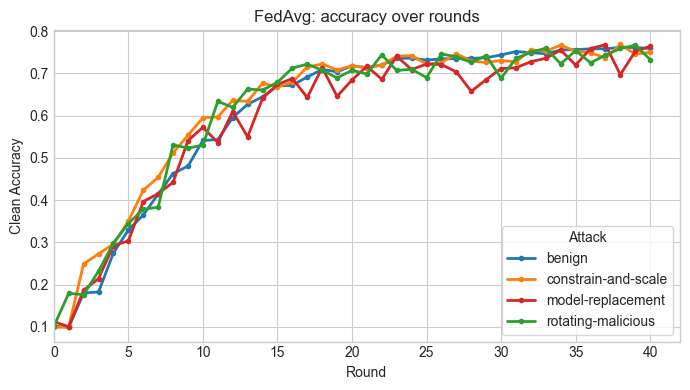

In [18]:
plot_one("accuracy", "Clean Accuracy", "FedAvg")

In [ ]:
plot_one("accuracy", "Clean Accuracy", "Trimmed-Mean")

In [ ]:
plot_one("accuracy", "Clean Accuracy", "Coordinate-wise Median")

In [ ]:
plot_one("poisoned_accuracy", "Backdoor Accuracy", "FedAvg")

In [ ]:
plot_one("poisoned_accuracy", "Backdoor Accuracy", "Trimmed-Mean")

In [ ]:
plot_one("poisoned_accuracy", "Backdoor Accuracy", "Coordinate-wise Median")

In [ ]:
plot_one("attack_success_rate", "Attack Success Rate", "FedAvg")

In [ ]:
plot_one("attack_success_rate", "Attack Success Rate", "Trimmed-Mean")

In [ ]:
plot_one("attack_success_rate", "Attack Success Rate", "Coordinate-wise Median")